# The Physical Basis of SST Measurements

## Motivation

Sea surface temperature (SST) is a major indicator of physical and biological ocean processes. It reflects the combined influence of air temperature, solar heating, nighttime cooling, evaporative cooling, wind mixing, and wave mixing near the air-ocean interface.

Satellite SST products allow us to assess changes in ocean temperature across large spatial scales and through time. However, satellite-derived SST is not a direct measurement of the full upper ocean. It is inferred from electromagnetic radiation emitted from the very surface of the ocean.

### Key Questions

Some key questions we might consider for measuring SST from spacing include:

- How can we relate infrared emission from the ocean surface to ocean temperature?
- What portion of the infrared spectrum can be observed by satellites?
- How much of the infrared radiation observed by satellites is emitted from ocean surface?

In the sections below, we'll use Python to generate some plots. Let's read in a few packages here:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Ocean Temperature and Electromagnetic Radiation

The ocean surface, like all objects with a temperature above absolute zero, emits electromagnetic radiation. To our introductory discussion, we'll approximate the ocean surface as a [blackbody](../fundamentals/blackbodies) that can efficiently absorb and emit thermal infrared radiation.

Recall that the wavelength at which a blackbody emits its peak radiation is related to its temperature by [Wien's Law](../fundamentals/blackbodies#wiens-law):

$$\lambda_{peak} = \frac{b}{T}$$

where:

- $\lambda_{peak}$ is the peak emission wavelength in meters
- $T$ is temperature in Kelvin
- $b = 2.898 \times 10^{-3}$ m K is Wien's displacement constant

Warmer objects emit more radiation overall and reach their peak emission at shorter wavelengths. Cooler objects emit less radiation overall and reach their peak emission at longer wavelengths.

We can use Wien's Law to estimate the wavelength of peak emission, say for a location in Monterey Bay. For example, we could use real-time data from the [M1 Buoy](https://www.ndbc.noaa.gov/station_page.php?station=46092) maintained by the Monterey Bay Aquarium Research Institute. On the time and day of this writing, the water temperature was 11.6$^{\circ}$C. Let run a quick calculation:

In [3]:
# Wien displacement constant (m K)
b = 2.898e-3  

# Ocean temperature from M1 Buoy
T_ocean_C = 11.6  # degrees C
T_ocean_K = T_ocean_C + 273.15

# Wien's Law
lambda_peak_m = b / T_ocean_K
lambda_peak_um = lambda_peak_m * 1e6

print(f'Ocean temperature: {T_ocean_C:.1f} °C = {T_ocean_K:.2f} K')
print(f'Peak wavelength: {lambda_peak_um:.2f} µm')

Ocean temperature: 11.6 °C = 284.75 K
Peak wavelength: 10.18 µm


By referencing our [Electromagnetic Spectrum](../fundamentals/em-spectrum#the-electromagnetic-spectrum) diagram, we can see that this wavelength is associated with the infrared part of the spectrum. Specifically, it is in the **thermal infrared**, which spans from approximately 3 $\mu$m to 15 $\mu$m. While this example is specific for Monterey Bay, we can verify that the range of temperature in the ocean are also in this range:

In [4]:
# Coldest polar temperature
T_polar_C = -2
T_polar_K = T_polar_C + 273.15
lambda_polar_um = (b / T_polar_K) * 1e6

# Warmest equatorial temperature
T_equatorial_C = 31
T_equatorial_K = T_equatorial_C + 273.15
lambda_equatorial_um = (b / T_equatorial_K) * 1e6

print(f'At {T_polar_C:.1f} °C, peak emission occurs near {lambda_polar_um:.2f} µm.')
print(f'At {T_equatorial_C:.1f} °C, peak emission occurs near {lambda_equatorial_um:.2f} µm.')

At -2.0 °C, peak emission occurs near 10.69 µm.
At 31.0 °C, peak emission occurs near 9.53 µm.


## Planck's Law and Ocean Thermal Emission

Wien's Law tells us where the peak emission occurs. While it would be ideal to observe the ocean surface at the range of wavelengths around the peak of ocean emission, that might not be possible from space - the atmospher in between may preferentially block some ocean-leaving radiation before it gets to the satellite. Further, the atmosphere itself will also be emitting thermal radiation!

If we'd like to know the irradiance leaving the ocean and we model it as a blackbody, [Planck's Law](../fundamentals/blackbodies#plancks-law) describes the full emission spectrum of a blackbody. Let's consider what this curve would look like for Monterey Bay by defining a function for Planck's Law and generating a quick plot:

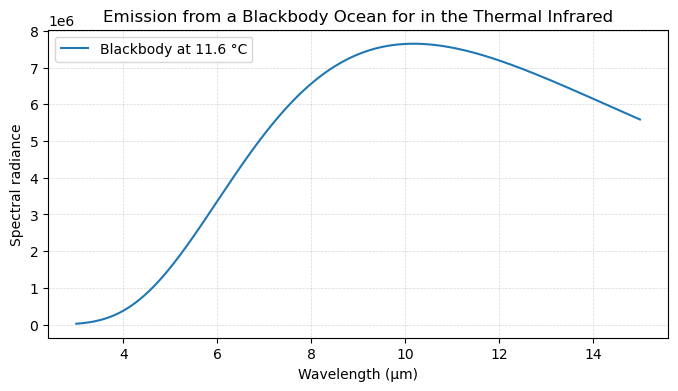

In [8]:
def plancks_law(wavelength_m, temperature_K):
    c = 2.9979e8      # speed of light (m/s)
    h = 6.626e-34     # Planck constant (J s)
    kB = 1.380e-23    # Boltzmann constant (J/K)
    Fp = (2*h*c**2 / wavelength_m**5) * (1 / (np.exp(h*c/(wavelength_m*kB*temperature_K)) - 1))
    return Fp

# Wavelengths from 3-15 µm converted to meters
wavelength_um = np.linspace(3, 15, 1000)
wavelength_m = wavelength_um * 1e-6

# Monterey Bay temperature
temperature_C = 11.6
temperature_K = temperatures_C + 273.15

# Figure
plt.figure(figsize=(8, 4))
radiance = plancks_law(wavelength_m, temperature_K)
plt.plot(wavelength_um, radiance, label=f'Blackbody at {temperature_C} °C')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Spectral radiance')
plt.title('Emission from a Blackbody Ocean for in the Thermal Infrared')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

As expected from our calculations above, the peak is 10.18 µm. However, we next have to consider: how much of this radiation passes through the atmosphere?

In [ ]:
plt.axvspan(3.5, 4.1, alpha=0.2, label='~4 µm window')
plt.axvspan(10.0, 12.5, alpha=0.2, label='~11 µm window')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Spectral radiance')
plt.title('Blackbody Emission for Ocean-like Temperatures')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

### Atmospheric Windows in the Thermal Infrared

For visible remote sensing, we often ask how much sunlight can travel downward through the atmosphere, reflect from the ocean, and travel back to the satellite. For thermal infrared SST retrievals, we ask a different question: how much radiation emitted upward from the ocean surface can pass through the atmosphere to the satellite?

The atmosphere absorbs strongly at many infrared wavelengths, especially due to water vapor. To get a sense for where the atmospheric windows are, we will utilize output from [Skymodel](https://www.eso.org/sci/software/pipelines/skytools/skymodel) - a model that estimates how Earth’s atmosphere changes incoming electromagnetic radiation by absorbing some wavelengths.

Let's read in the output from a model run and plot it here:

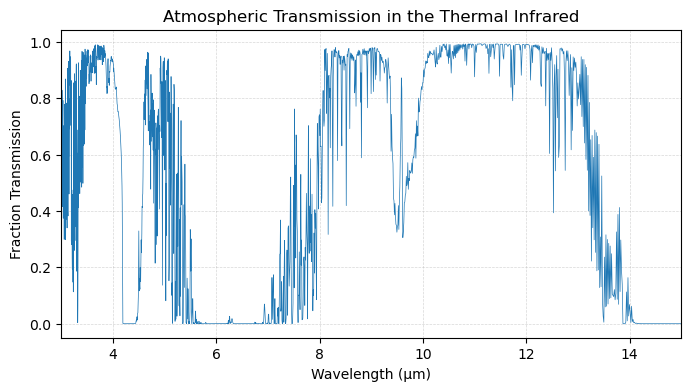

In [13]:
# read in the data
skymodel_data = np.genfromtxt('../data/sst/skycalc_blackbody_transmission_3to15um.csv',
                            delimiter=',', skip_header=1)

# Figure
plt.figure(figsize=(8, 4))
plt.plot(skymodel_data[:,0], skymodel_data[:,1], linewidth=0.5)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Fraction Transmission')
plt.title('Atmospheric Transmission in the Thermal Infrared')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.xlim([3,15])
plt.show()

As we can see, there is a decline in transmission around 9-10 µm - not ideal for our ocean temperatures. This decline is associated with absorption by atmospheric ozone.

To get a sense for how this maps onto the radiance from the ocean surface, we can apply this fractional transmission to our blackbody curve:

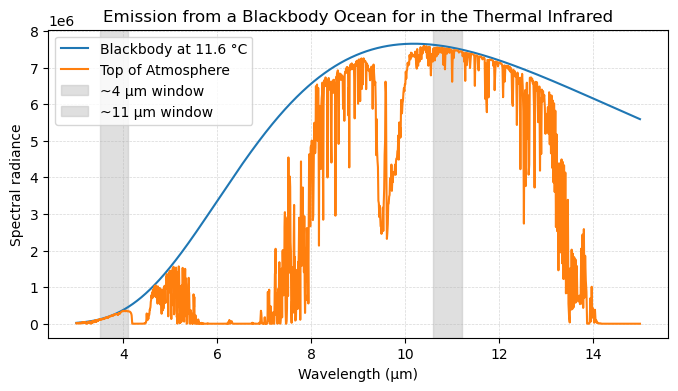

In [22]:
# Monterey Bay temperature
temperature_C = 11.6
temperature_K = temperatures_C + 273.15

# compute radiances
radiance_blackbody = plancks_law(skymodel_data[:,0]*1e-6, temperature_K)
radiance_TOA = radiance_blackbody * skymodel_data[:,1]

# Figure
plt.figure(figsize=(8, 4))
plt.plot(skymodel_data[:,0], radiance_blackbody, label=f'Blackbody at {temperature_C} °C')
plt.plot(skymodel_data[:,0], radiance_TOA, label=f'Top of Atmosphere')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Spectral radiance')
plt.title('Emission from a Blackbody Ocean for in the Thermal Infrared')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvspan(3.5, 4.1, alpha=0.5, label='~4 µm window', color='silver')
plt.axvspan(10.6, 11.2, alpha=0.5, label='~11 µm window', color='silver')
plt.legend()
plt.show()

Here, we see that there are two atmospheric windows for thermal radiation from the ocean surface: one around **4 µm** and one around  **11 µm**. There is a trade-off: the 4 µm region can have lower water-vapor impact, but the ocean emits much less energy there than near 11 µm for ocean temperatures. The 4 µm window can be useful at night because daytime sun glint can overwhelm the thermal signal. The 11 µm window is used for both day and night SST retrievals.

## Thermal Infrared Absorption at the Ocean Surface

Infrared radiation is absorbed very quickly by liquid water. The thermal infrared radiation observed by satellites is emitted from approximately the upper **1 µm** of the ocean.

This means satellite infrared SST is a measurement of the ocean **skin temperature**, not the temperature of the full upper mixed layer.

## Skin SST vs Bulk SST

**Skin SST** refers to the temperature of the very surface of the ocean inferred from emitted infrared radiation.

**Bulk SST** refers to temperatures measured deeper in the upper ocean, often in the top meter, using in situ instruments or represented in models.

Skin and bulk SST can differ by about ±1 K or more depending on mixing, wind speed, solar heating, nighttime cooling, and stratification. In daytime, the skin may be biased slightly warm under strong solar heating. At night, the skin is often slightly cooler because of heat loss from the surface.

### Summary

Satellite SST retrievals rely on the relationship between temperature and thermal infrared emission. Because infrared radiation comes from only the ocean skin and must pass through the atmosphere, satellite SST is not a simple direct measurement of bulk upper-ocean temperature.

Key ideas:

1. Ocean-like temperatures emit peak radiation in the thermal infrared.
2. Infrared SST retrievals measure the ocean skin, not the full upper mixed layer.